In [ ]:
Partie 1 : Exploration et visualisation des données

In [29]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import os

In [41]:
BATCH_SIZE = 32
IMG_HEIGHT = 256 # Set to 256 as per your dataset overview
IMG_WIDTH = 256  # Set to 256 as per your dataset overview

# !!! CRITICAL: UPDATE THIS PATH !!!
# Replace 'VOTRE_CHEMIN_ABSOLU_VERS_VOTRE_JEU_DE_DONNEES_14_CLASSES' with the actual, absolute path
# to your 14-class flower dataset. For example: '/content/my_14_class_flowers'
# Ensure this path contains 'train' and 'val' subdirectories, each with 14 class subfolders.
DATA_DIR = 'VOTRE_CHEMIN_ABSOLU_VERS_VOTRE_JEU_DE_DONNEES_14_CLASSES'

# Construct full paths for training and validation directories
train_dir_path = os.path.join(DATA_DIR, 'train')
val_dir_path = os.path.join(DATA_DIR, 'val')

In [ ]:
# Create the training dataset
# Assuming dataset is already split into 'train' and 'val' subdirectories
print(f"Loading training data from: {train_dir_path}")
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir_path,
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Create the validation dataset
print(f"Loading validation data from: {val_dir_path}")
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir_path,
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Get class names
class_names = train_ds.class_names
print(f"Class Names: {class_names}")

In [31]:
# Print the number of images per class in the training dataset
class_counts = {class_name: 0 for class_name in class_names}

# Iterate through the dataset to count images per class
# Note: This might be slow for very large datasets
for images, labels in train_ds:
    for label in labels:
        class_counts[class_names[label.numpy()]] += 1

print("\nNumber of images per class (Training Set):")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count} images")


Number of images per class (Training Set):
daisy: 504 images
dandelion: 722 images
roses: 521 images
sunflowers: 547 images
tulips: 642 images


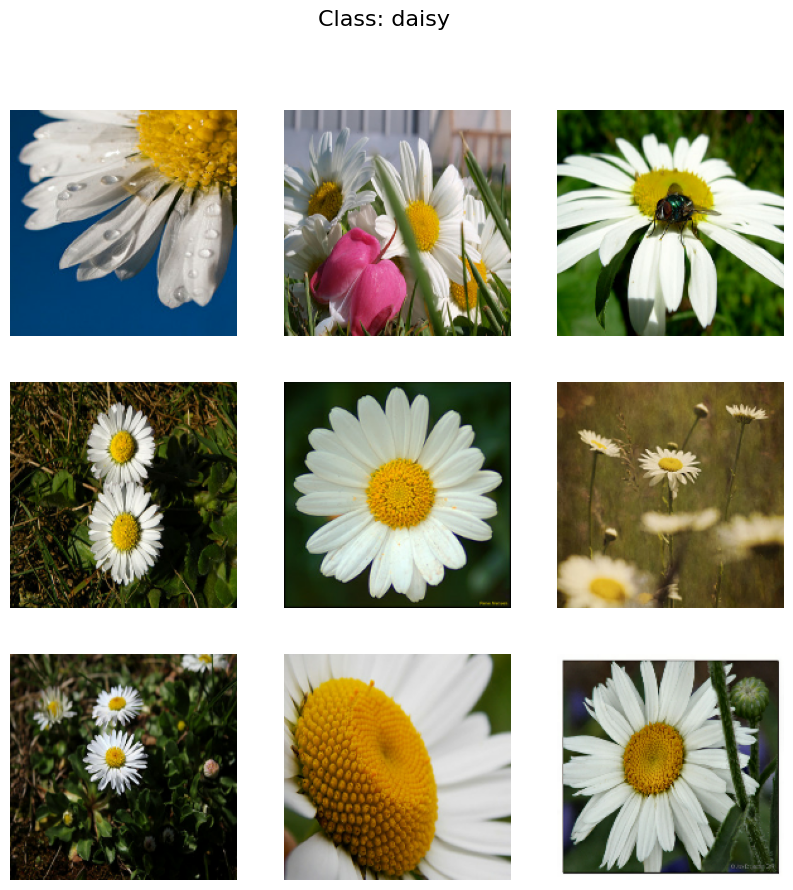

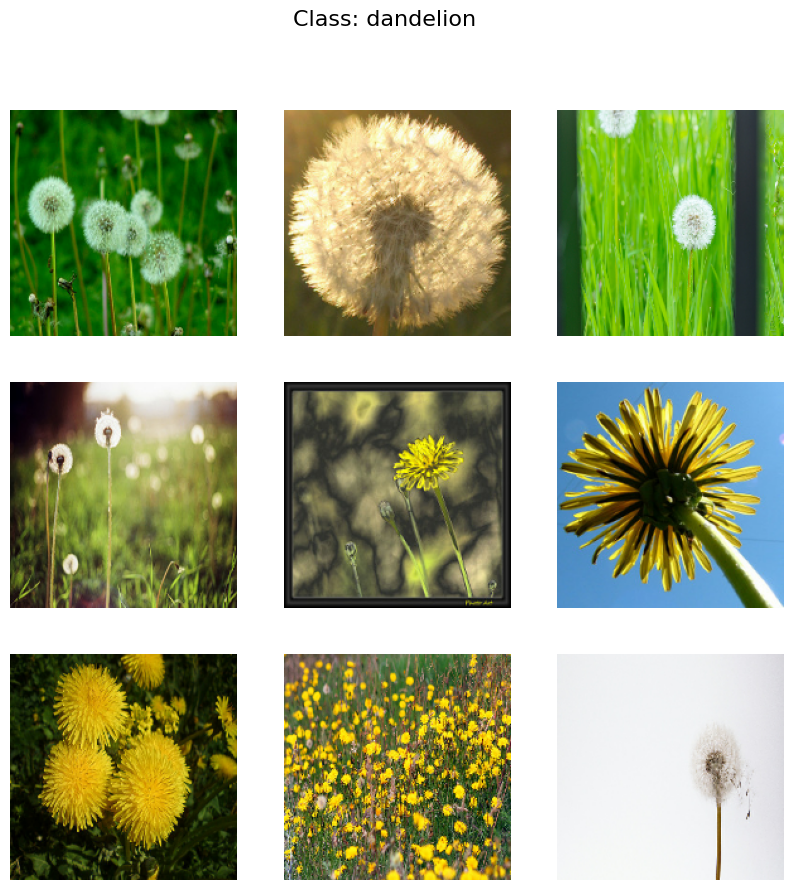

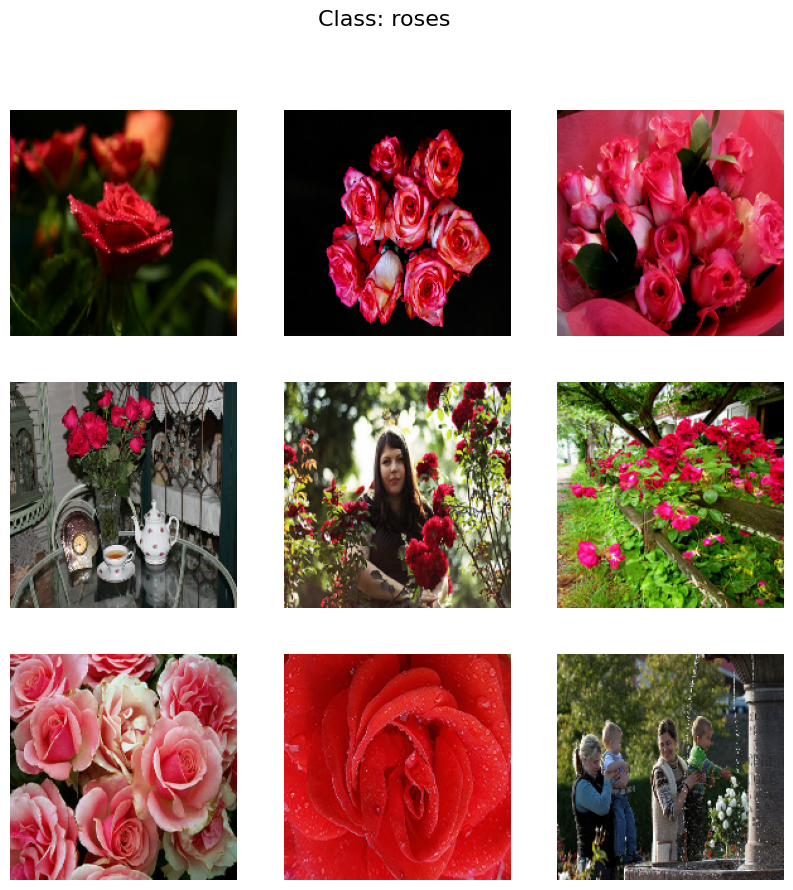

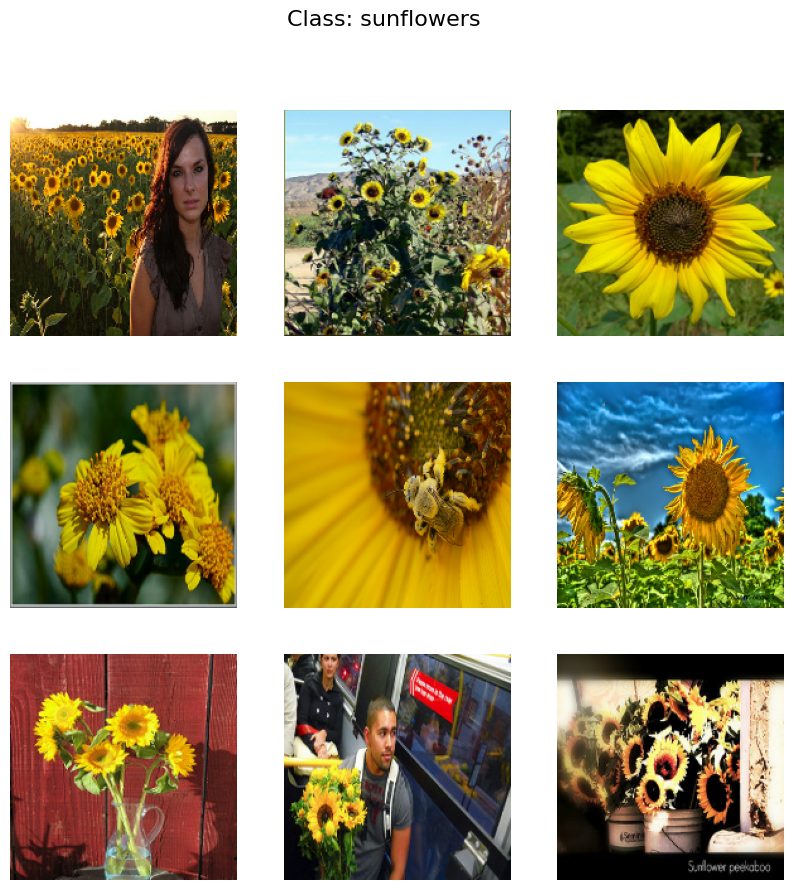

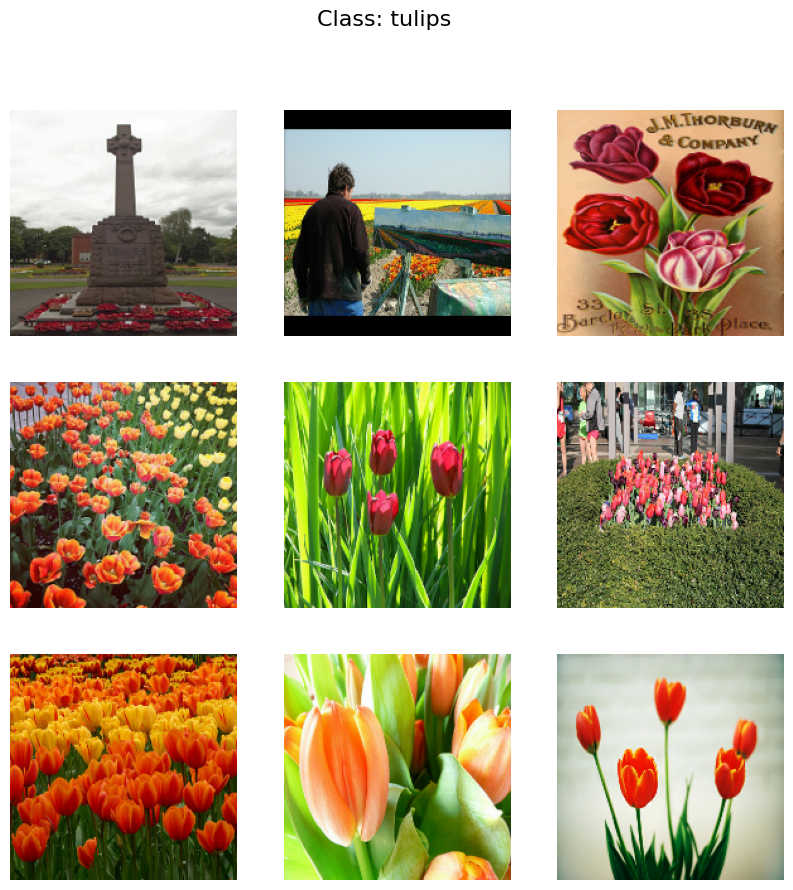

In [32]:
def visualize_images(dataset, class_names, num_images_per_class=9):
    for class_name in class_names:
        plt.figure(figsize=(10, 10))
        plt.suptitle(f"Class: {class_name}", fontsize=16)
        count = 0
        images_for_class = []

        # Collect images for the current class
        for images, labels in dataset:
            for i in range(len(images)):
                if class_names[labels[i].numpy()] == class_name:
                    images_for_class.append(images[i].numpy().astype("uint8"))
                    if len(images_for_class) >= num_images_per_class:
                        break
            if len(images_for_class) >= num_images_per_class:
                break

        # Display the collected images
        for i in range(min(len(images_for_class), num_images_per_class)):
            ax = plt.subplot(int(np.sqrt(num_images_per_class)), int(np.ceil(num_images_per_class/np.sqrt(num_images_per_class))), i + 1)
            plt.imshow(images_for_class[i])
            plt.axis("off")
        plt.show()

# Visualize images for each class from the training dataset
visualize_images(train_ds, class_names)

#### **Analyse des images et difficultés de classification prévues :**

(Veuillez remplir cette section après avoir observé les images visualisées. Considérez les aspects suivants :)

*   **Couleurs et formes similaires :** Les différentes espèces de fleurs partagent-elles des palettes de couleurs ou des formes générales similaires, ce qui les rend difficiles à distinguer ?
*   **Variations au sein d'une même espèce :** Existe-t-il des variations significatives de couleur, de taille ou d'agencement des pétales au sein d'une même espèce de fleur ?
*   **Encombrement de l'arrière-plan :** L'arrière-plan est-il souvent chargé ou similaire aux couleurs des fleurs, ce qui pourrait distraire le modèle ?
*   **Variations d'éclairage et de pose :** Existe-t-il diverses conditions d'éclairage ou des angles/poses différentes des fleurs qui pourraient poser des défis ?
*   **Résolution et qualité :** La qualité de l'image est-elle constante ? Certaines images sont-elles floues ou de basse résolution ?
*   **Occlusion :** Des parties des fleurs sont-elles souvent cachées par des feuilles ou d'autres objets ?

**Exemples de considérations :**

*   « De nombreuses espèces, comme la 'marguerite' et le 'pissenlit', semblent avoir des teintes blanches/jaunes similaires et une symétrie radiale, ce qui pourrait entraîner une confusion. »
*   « Il existe une variation notable de la densité des pétales et de la saturation des couleurs même au sein de la classe 'rose', suggérant une variance intra-classe. »
*   « Certaines images présentent des arrière-plans complexes avec d'autres feuillages, ce qui pourrait amener le modèle à se concentrer sur des caractéristiques non pertinentes. »
*   « L'ensemble de données semble inclure des images prises sous différents éclairages, de la lumière du soleil vive aux conditions plus sombres, ce qui ajoute au défi de la classification. »

Partie 2 : Conception de l'architecture du modèle


In [33]:
from tensorflow.keras import layers, models

In [34]:
# Define the number of classes based on the loaded dataset
num_classes = len(class_names)

# Model architecture
model = models.Sequential([
    # Input layer: Rescale pixel values to [0, 1]
    layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Third Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Flatten the output for the Dense layers
    layers.Flatten(),

    # Dense layers
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax') # Output layer for classification
])

# Compile the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    33,554,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,651,141 (128.37 MB)

 Trainable params: 33,650,181 (128.37 MB)

 Non-trainable params: 960 (3.75 KB)

### Justification des choix architecturaux :

1.  **`layers.Rescaling(1./255)`**:
    *   **Pourquoi :** Normalise les valeurs de pixels de 0-255 à 0-1. Cela aide le modèle à mieux apprendre et accélère la convergence. C'est une étape de prétraitement standard pour les réseaux neuronaux, en particulier pour les images.

2.  **`layers.Conv2D(filtres, (taille_noyau, taille_noyau), activation='relu', padding='same')`**:
    *   **Pourquoi :** Les couches de convolution sont la pierre angulaire des CNNs. Elles extraient des caractéristiques hiérarchiques des images (des bords aux formes plus complexes).
    *   **Nombre de filtres (32, 64, 128) :** Nous commençons avec un nombre plus petit de filtres et l'augmentons progressivement dans les couches plus profondes. Cela permet au modèle d'apprendre des caractéristiques plus complexes à mesure qu'il progresse dans le réseau. Le fait de doubler les filtres à chaque couche est une pratique courante.
    *   **`taille_noyau=(3, 3)` :** Les petits noyaux (comme 3x3) sont efficaces pour capturer les caractéristiques locales sans ajouter trop de paramètres, ce qui réduit le risque de surapprentissage.
    *   **`activation='relu'` :** La fonction d'activation ReLU (Rectified Linear Unit) introduit la non-linéarité dans le modèle, permettant d'apprendre des relations complexes. Elle est computationnellement efficace et aide à atténuer le problème des gradients évanescents.
    *   **`padding='same'` :** Garantit que la taille spatiale de la sortie de la convolution est la même que l'entrée, ce qui aide à préserver les informations spatiales et facilite la conception de l'architecture.

3.  **`layers.BatchNormalization()`**:
    *   **Pourquoi :** Normalise les activations des couches précédentes pour chaque mini-batch. Cela stabilise le processus d'entraînement, réduit la dépendance à l'initialisation des poids et permet des taux d'apprentissage plus élevés, ce qui conduit souvent à une convergence plus rapide et à de meilleures performances.

4.  **`layers.MaxPooling2D((2, 2))`**:
    *   **Pourquoi :** Réduit la dimension spatiale de la sortie de la convolution, ce qui diminue le nombre de paramètres et les calculs dans les couches suivantes, aide à contrôler le surapprentissage et rend le modèle plus robuste aux petites translations et déformations des images.

5.  **`layers.Dropout(taux)`**:
    *   **Pourquoi :** Une technique de régularisation où un pourcentage aléatoire de neurones est désactivé pendant l'entraînement. Cela empêche le surapprentissage en forçant le réseau à apprendre des représentations plus robustes, car aucun neurone unique ne peut devenir trop dépendant de la présence d'un neurone particulier d'une couche précédente.
    *   **Taux (0.25, 0.5) :** Des taux plus élevés sont souvent utilisés dans les couches denses finales (0.5) car elles ont plus de paramètres et sont plus sujettes au surapprentissage, tandis que des taux plus faibles (0.25) peuvent être utilisés après les couches convolutives.

6.  **`layers.Flatten()`**:
    *   **Pourquoi :** Convertit la sortie 2D ou 3D des couches convolutionnelles/pooling en un vecteur 1D, qui peut ensuite être alimenté aux couches denses (fully connected).

7.  **`layers.Dense(unités, activation='relu'/'softmax')`**:
    *   **Pourquoi :** Les couches denses sont utilisées pour la classification. La couche dense intermédiaire (256 unités) aide le modèle à combiner les caractéristiques de haut niveau extraites par les couches convolutives.
    *   **`activation='relu'` pour la couche cachée :** Comme mentionné précédemment, pour la non-linéarité.
    *   **`layers.Dense(num_classes, activation='softmax')` pour la couche de sortie :** La couche de sortie a autant de neurones qu'il y a de classes. La fonction d'activation `softmax` convertit les sorties en probabilités, où la somme de toutes les probabilités est égale à 1, ce qui est idéal pour les problèmes de classification multi-classes.

8.  **Optimiseur (`'adam'`) et fonction de perte (`SparseCategoricalCrossentropy`)**:
    *   **`adam` :** Un algorithme d'optimisation adaptatif populaire qui est généralement un bon point de départ car il est efficace et performant dans de nombreux scénarios.
    *   **`SparseCategoricalCrossentropy` :** Utilisé lorsque les étiquettes de classe sont des entiers (comme 0, 1, 2, ...), ce qui est le cas avec `image_dataset_from_directory`. `from_logits=False` est spécifié car la couche de sortie utilise une activation `softmax` qui produit déjà des probabilités.



Partie 3 : Optimisation des hyperparamètres


### Avant de lancer les expériences d'optimisation des hyperparamètres :

**1. Mettez à jour `DATA_DIR`:**
   Dans la classe `Config` ci-dessous, modifiez la variable `DATA_DIR` pour qu'elle pointe vers le chemin absolu de votre jeu de données de fleurs sur Google Drive. Par exemple : `/content/drive/MyDrive/mon_jeu_de_donnees_fleurs_14_classes`.
   Assurez-vous que ce chemin contient les sous-répertoires `train` et `val`, chacun avec les sous-dossiers de classes correspondants.

**2. Vérifiez `NUM_CLASSES`:**
   La variable `NUM_CLASSES` dans la classe `Config` est actuellement définie sur `5` pour correspondre aux classes détectées précédemment. Si vous utilisez un jeu de données avec 14 classes, veuillez mettre à jour `NUM_CLASSES = 14`.

Une fois que vous avez mis à jour ces variables, exécutez la cellule ci-dessous pour initialiser le processus d'optimisation.

In [67]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time
import os
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuration
class Config:
    IMG_SIZE = (256, 256) # Updated to 256x256 as per your specification
    BATCH_SIZE = 32
    NUM_CLASSES = 5 # Currently detected 5 classes. Update this to 14 if using a 14-class dataset.
    EPOCHS = 30
    DATA_DIR = 'VOTRE_CHEMIN_ABSOLU_VERS_VOTRE_JEU_DE_DONNEES_14_CLASSES'  # À modifier: REMPLACEZ CE CHEMIN !
    SEED = 42
    VALIDATION_SPLIT = 0.2

# Set seeds
tf.random.set_seed(Config.SEED)
np.random.seed(Config.SEED)

# 1. Fonction de chargement des données améliorée
def load_data(batch_size=Config.BATCH_SIZE, img_size=Config.IMG_SIZE):
    """Charge et prépare le jeu de données"""

    train_ds = tf.keras.preprocessing.image_dataset_from_directory(
        os.path.join(Config.DATA_DIR, 'train'),
        validation_split=Config.VALIDATION_SPLIT,
        subset='training',
        seed=Config.SEED,
        image_size=img_size,
        batch_size=batch_size,
        label_mode='int'  # Pour sparse_categorical_crossentropy
    )

    val_ds = tf.keras.preprocessing.image_dataset_from_directory(
        os.path.join(Config.DATA_DIR, 'val'),
        validation_split=Config.VALIDATION_SPLIT,
        subset='validation',
        seed=Config.SEED,
        image_size=img_size,
        batch_size=batch_size,
        label_mode='int'
    )

    class_names = train_ds.class_names
    num_classes = len(class_names)

    # Normalisation
    normalization_layer = layers.Rescaling(1./255)

    train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
    val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

    # Data augmentation optimisée
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"), # Flipping
        layers.RandomRotation(0.2), # Rotation
        layers.RandomZoom(0.15), # Zooming
        layers.RandomTranslation(height_factor=0.1, width_factor=0.1), # Shifting
        layers.RandomShear(0.1), # Shearing
    ])

    # Application de l'augmentation uniquement sur l'entraînement
    train_ds = train_ds.map(
        lambda x, y: (data_augmentation(x, training=True), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Optimisation des performances
    train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds, class_names, num_classes

# 2. Modèles améliorés
def create_model(input_shape=(256, 256, 3), num_classes=5, architecture='simple'): # Updated input_shape
    """Crée différents modèles"""

    if architecture == 'simple':
        model = models.Sequential([
            layers.Input(shape=input_shape),
            layers.Conv2D(32, 3, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D(2),
            layers.Dropout(0.2),

            layers.Conv2D(64, 3, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D(2),
            layers.Dropout(0.2),

            layers.Conv2D(128, 3, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D(2),
            layers.Dropout(0.2),

            layers.GlobalAveragePooling2D(),
            layers.Dropout(0.5),
            layers.Dense(128, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.5),
            layers.Dense(num_classes, activation='softmax')
        ])

    elif architecture == 'deep':
        model = models.Sequential([
            layers.Input(shape=input_shape),

            # Bloc 1
            layers.Conv2D(32, 3, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.Conv2D(32, 3, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D(2),
            layers.Dropout(0.2),

            # Bloc 2
            layers.Conv2D(64, 3, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.Conv2D(64, 3, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D(2),
            layers.Dropout(0.2),

            # Bloc 3
            layers.Conv2D(128, 3, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.Conv2D(128, 3, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D(2),
            layers.Dropout(0.2),

            # Bloc 4
            layers.Conv2D(256, 3, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPooling2D(2),
            layers.Dropout(0.3),

            layers.GlobalAveragePooling2D(),
            layers.Dropout(0.5),
            layers.Dense(256, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.5),
            layers.Dense(128, activation='relu'),
            layers.BatchNormalization(),
            layers.Dense(num_classes, activation='softmax')
        ])

    elif architecture == 'transfer':
        base_model = tf.keras.applications.MobileNetV2(
            input_shape=input_shape,
            include_top=False,
            weights='imagenet',
            pooling='avg'
        )
        base_model.trainable = False

        model = models.Sequential([
            layers.Input(shape=input_shape),
            base_model,
            layers.Dropout(0.2),
            layers.Dense(num_classes, activation='softmax')
        ])

    return model

# 3. Fonctions de learning rate scheduling améliorées
def get_callbacks(config):
    """Crée les callbacks pour l'entraînement"""

    callbacks = []

    # Early stopping
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=0
    )
    callbacks.append(early_stopping)

    # Reduce learning rate on plateau
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=0
    )
    callbacks.append(reduce_lr)

    # Model checkpoint
    checkpoint = ModelCheckpoint(
        f'best_model_{config["name"]}.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
    callbacks.append(checkpoint)

    # CSV logger
    csv_logger = CSVLogger(f'history_{config["name"]}.csv', append=True)
    callbacks.append(csv_logger)

    return callbacks

# 4. Configurations d'hyperparamètres
def get_hyperparameter_configs():
    """Définit les configurations à tester"""

    configs = [
        # Optimiseurs
        {
            'name': 'Adam_LR_0.001',
            'optimizer': 'adam',
            'learning_rate': 0.001,
            'batch_size': 32,
            'architecture': 'deep'
        },
        {
            'name': 'Adam_LR_0.0001',
            'optimizer': 'adam',
            'learning_rate': 0.0001,
            'batch_size': 32,
            'architecture': 'deep'
        },
        {
            'name': 'RMSprop_LR_0.001',
            'optimizer': 'rmsprop',
            'learning_rate': 0.001,
            'batch_size': 32,
            'architecture': 'deep'
        },
        {
            'name': 'SGD_LR_0.01_Momentum',
            'optimizer': 'sgd',
            'learning_rate': 0.01,
            'batch_size': 32,
            'architecture': 'deep'
        },

        # Batch sizes
        {
            'name': 'Adam_Batch_16',
            'optimizer': 'adam',
            'learning_rate': 0.001,
            'batch_size': 16,
            'architecture': 'deep'
        },
        {
            'name': 'Adam_Batch_64',
            'optimizer': 'adam',
            'learning_rate': 0.001,
            'batch_size': 64,
            'architecture': 'deep'
        },

        # Architectures
        {
            'name': 'Adam_Simple_CNN',
            'optimizer': 'adam',
            'learning_rate': 0.001,
            'batch_size': 32,
            'architecture': 'simple'
        },
        {
            'name': 'Adam_Transfer_Learning',
            'optimizer': 'adam',
            'learning_rate': 0.001,
            'batch_size': 32,
            'architecture': 'transfer'
        }
    ]

    return configs

# 5. Fonction d'entraînement améliorée
def train_and_evaluate(config):
    """Entraîne et évalue un modèle"""

    print(f"\n{'='*70}")
    print(f"📊 Expérience: {config['name']}")
    print(f"{'='*70}")
    print(f"Optimizer: {config['optimizer']}")
    print(f"Learning Rate: {config['learning_rate']}")
    print(f"Batch Size: {config['batch_size']}")
    print(f"Architecture: {config['architecture']}")

    # Chargement des données
    train_ds, val_ds, class_names, num_classes = load_data(
        batch_size=config['batch_size']
    )

    # Création du modèle
    model = create_model(
        input_shape=(*Config.IMG_SIZE, 3),
        num_classes=num_classes,
        architecture=config['architecture']
    )

    # Configuration de l'optimiseur
    if config['optimizer'] == 'adam':
        optimizer = Adam(learning_rate=config['learning_rate'])
    elif config['optimizer'] == 'rmsprop':
        optimizer = RMSprop(learning_rate=config['learning_rate'])
    elif config['optimizer'] == 'sgd':
        optimizer = SGD(
            learning_rate=config['learning_rate'],
            momentum=0.9,
            nesterov=True
        )

    # Compilation
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Affichage du résumé du modèle
    model.summary()

    # Callbacks
    callbacks = get_callbacks(config)

    # Entraînement
    print("\n🚀 Début de l'entraînement...")
    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=Config.EPOCHS,
        callbacks=callbacks,
        verbose=0
    )

    training_time = time.time() - start_time

    # Évaluation
    val_loss, val_acc = model.evaluate(val_ds, verbose=0)
    train_loss, train_acc = model.evaluate(train_ds, verbose=0)

    # Meilleure époque
    best_epoch = np.argmax(history.history['val_accuracy']) + 1
    best_val_acc = max(history.history['val_accuracy'])
    best_train_acc = max(history.history['accuracy'])
    best_val_loss = min(history.history['val_loss'])

    # Résultats
    results = {
        'config_name': config['name'],
        'optimizer': config['optimizer'],
        'learning_rate': config['learning_rate'],
        'batch_size': config['batch_size'],
        'architecture': config['architecture'],
        'epochs_trained': len(history.history['loss']),
        'best_epoch': best_epoch,
        'best_train_accuracy': best_train_acc,
        'best_val_accuracy': best_val_acc,
        'best_val_loss': best_val_loss,
        'final_val_accuracy': val_acc,
        'final_train_accuracy': train_acc,
        'training_time': training_time,
        'history': history,
        'model': model
    }

    # Affichage des résultats
    print(f"\n✅ Résultats:")
    print(f"  Meilleure précision validation: {best_val_acc:.4f}")
    print(f"  Meilleure précision entraînement: {best_train_acc:.4f}")
    print(f"  Meilleure époque: {best_epoch}")
    print(f"  Temps d'entraînement: {training_time:.1f}s")

    return results

# 6. Visualisation améliorée
def plot_results(results_dict):
    """Visualise les résultats de toutes les expériences"""

    n_experiments = len(results_dict)
    fig, axes = plt.subplots(n_experiments, 2, figsize=(15, 4*n_experiments))

    if n_experiments == 1:
        axes = axes.reshape(1, -1)

    for idx, (name, results) in enumerate(results_dict.items()):
        history = results['history']
        epochs = range(1, len(history.history['accuracy']) + 1)

        # Accuracy
        axes[idx, 0].plot(epochs, history.history['accuracy'], 'b-', label='Entraînement')
        axes[idx, 0].plot(epochs, history.history['val_accuracy'], 'r-', label='Validation')
        axes[idx, 0].set_title(f'{name} - Accuracy', fontsize=12, fontweight='bold')
        axes[idx, 0].set_xlabel('Epochs')
        axes[idx, 0].set_ylabel('Accuracy')
        axes[idx, 0].legend()
        axes[idx, 0].grid(True, alpha=0.3)
        axes[idx, 0].set_ylim([0, 1])

        # Loss
        axes[idx, 1].plot(epochs, history.history['loss'], 'b-', label='Entraînement')
        axes[idx, 1].plot(epochs, history.history['val_loss'], 'r-', label='Validation')
        axes[idx, 1].set_title(f'{name} - Loss', fontsize=12, fontweight='bold')
        axes[idx, 1].set_xlabel('Epochs')
        axes[idx, 1].set_ylabel('Loss')
        axes[idx, 1].legend()
        axes[idx, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 7. Tableau récapitulatif
def create_summary_table(results_dict):
    """Crée un tableau récapitulatif"""

    data = []
    for name, results in results_dict.items():
        data.append({
            'Expérience': name,
            'Optimizer': results['optimizer'],
            'LR': results['learning_rate'],
            'Batch': results['batch_size'],
            'Architecture': results['architecture'][:10],
            'Meilleur Val Acc': f"{results['best_val_accuracy']:.4f}",
            'Meilleur Train Acc': f"{results['best_train_accuracy']:.4f}",
            'Epochs': results['epochs_trained'],
            'Temps (s)': f"{results['training_time']:.1f}"
        })

    df = pd.DataFrame(data)
    return df.sort_values('Meilleur Val Acc', ascending=False)

# 8. Programme principal
def main():
    """Fonction principale"""

    print("\n" + "="*70)
    print("🌸 TUNING DES HYPERPARAMÈTRES - CLASSIFICATION DE FLEURS")
    print("="*70)

    # Vérification du répertoire
    if not os.path.exists(Config.DATA_DIR):
        print(f"⚠️  Le répertoire {Config.DATA_DIR} n'existe pas!")
        print("Veuillez définir le bon chemin dans Config.DATA_DIR")
        return None, None # Explicitly return None, None to avoid TypeError

    # Chargement des données pour vérification
    train_ds, val_ds, class_names, num_classes = load_data()
    print(f"\n📁 Classes trouvées: {len(class_names)}")
    for i, name in enumerate(class_names):
        print(f"  - {i}: {name}")

    # Configurations
    configs = get_hyperparameter_configs()
    print(f"\n🔬 Nombre d'expériences à réaliser: {len(configs)}")

    # Lancement des expériences
    results_dict = {}
    for i, config in enumerate(configs, 1):
        print(f"\n{'='*70}")
        print(f"Expérience {i}/{len(configs)}")

        try:
            results = train_and_evaluate(config)
            results_dict[config['name']] = results

            # Sauvegarde intermédiaire
            with open('results.json', 'w') as f:
                temp_results = {k: {**v, 'history': None, 'model': None}
                               for k, v in results_dict.items()}
                json.dump(temp_results, f, indent=2)

        except Exception as e:
            print(f"❌ Erreur lors de l'expérience {config['name']}: {e}")
            import traceback
            traceback.print_exc()
            continue

    # Analyse des résultats
    if results_dict:
        print("\n" + "="*70)
        print("📊 RÉSULTATS FINAUX")
        print("="*70)

        # Tableau récapitulatif
        summary_df = create_summary_table(results_dict)
        print("\nTableau comparatif:")
        print(summary_df.to_string(index=False))

        # Meilleure configuration
        best_config = summary_df.iloc[0]
        print("\n" + "="*70)
        print("🏆 MEILLEURE CONFIGURATION")
        print("="*70)
        print(f"Expérience: {best_config['Expérience']}")
        print(f"Optimizer: {best_config['Optimizer']}")
        print(f"Learning Rate: {best_config['LR']}")
        print(f"Batch Size: {best_config['Batch']}")
        print(f"Architecture: {best_config['Architecture']}")
        print(f"Meilleure Précision Validation: {best_config['Meilleur Val Acc']}")
        print(f"Epochs d'entraînement: {best_config['Epochs']}")

        # Visualisation
        plot_results(results_dict)

        # Sauvegarde finale
        summary_df.to_csv('hyperparameter_tuning_results.csv', index=False)
        print("\n💾 Résultats sauvegardés dans 'hyperparameter_tuning_results.csv'")

        return results_dict, best_config
    else:
        print("❌ Aucun résultat valide")
        return None, None

# 9. Test rapide d'une configuration
def quick_test():
    """Test rapide avec une seule configuration"""

    config = {
        'name': 'Quick_Test',
        'optimizer': 'adam',
        'learning_rate': 0.001,
        'batch_size': 32,
        'architecture': 'deep'
    }

    results = train_and_evaluate(config)
    print(f"\nRésultats du test rapide:")
    print(f"Meilleure validation accuracy: {results['best_val_accuracy']:.4f}")

    return results

# Exécution
if __name__ == "__main__":
    # Pour un test rapide, décommentez la ligne suivante
    # results = quick_test()

    # Pour le tuning complet
    results_dict, best_config = main()


🌸 TUNING DES HYPERPARAMÈTRES - CLASSIFICATION DE FLEURS
⚠️  Le répertoire VOTRE_CHEMIN_ABSOLU_VERS_VOTRE_JEU_DE_DONNEES_14_CLASSES n'existe pas!
Veuillez définir le bon chemin dans Config.DATA_DIR


### Journal des Expériences et Résultats d'Optimisation des Hyperparamètres

Utilisez cette section pour consigner vos différentes expériences d'optimisation des hyperparamètres. Pour chaque expérience, notez les paramètres que vous avez modifiés et les performances résultantes.

**Objectif :** Atteindre la meilleure précision de validation possible sans surapprentissage excessif.

----

**Expérience 1 : Configuration initiale (Exemple)**

*   **Optimiseur :** Adam
*   **Taux d'apprentissage initial :** 0.001
*   **Taille du lot :** 32
*   **Fonction de perte :** `SparseCategoricalCrossentropy`
*   **Callbacks :** EarlyStopping (patience=7), ReduceLROnPlateau (factor=0.5, patience=3, min_lr=1e-7)
*   **Architecture :** `deep`

**Résultats (après exécution de la cellule d'entraînement) :**
*   **Précision d'entraînement finale :** [Insérer ici]
*   **Précision de validation finale :** [Insérer ici]
*   **Loss d'entraînement finale :** [Insérer ici]
*   **Loss de validation finale :** [Insérer ici]
*   **Nombre d'epochs exécutées :** [Insérer ici]
*   **Observations :** [Décrire le comportement, ex: "Le modèle a convergé rapidement mais la validation accuracy a plafonné."]

----

**Expérience 2 : [Nom de votre choix]**

*   **Optimiseur :** [Ex: RMSprop]
*   **Taux d'apprentissage initial :** [Ex: 0.0005]
*   **Taille du lot :** [Ex: 64]
*   **Fonction de perte :** `SparseCategoricalCrossentropy` (ou autre si vous avez expérimenté)
*   **Callbacks :** [Ex: EarlyStopping (patience=15)]
*   **Architecture :** [Ex: `simple` ou `transfer`]

**Résultats :**
*   **Précision d'entraînement finale :** [Insérer ici]
*   **Précision de validation finale :** [Insérer ici]
*   **Loss d'entraînement finale :** [Insérer ici]
*   **Loss de validation finale :** [Insérer ici]
*   **Nombre d'epochs exécutées :** [Insérer ici]
*   **Observations :** [Décrire les changements par rapport à l'expérience précédente, ex: "L'utilisation de RMSprop a légèrement amélioré la stabilité mais n'a pas augmenté la précision de manière significative."]

----

**Expérience 3 : [Nom de votre choix]**

*   ...

----

**Combinaison d'hyperparamètres ayant donné les meilleures performances :**

[Décrire les hyperparamètres de l'expérience la plus performante et justifier brièvement pourquoi cela a fonctionné le mieux.]

In [65]:
import random

class Game:
    """Représente une partie de Pierre-Feuille-Ciseaux contre l'ordinateur."""

    ITEMS = ["pierre", "feuille", "ciseaux"]

    def get_user_item(self):
        """
        Demande à l'utilisateur de choisir un élément (pierre/feuille/ciseaux).
        Répète la question jusqu'à ce que la saisie soit valide.

        Retourne :
            str : l'élément choisi par l'utilisateur.
        """
        while True:
            choix = input("Choisissez pierre, feuille ou ciseaux : ").strip().lower()
            if choix in self.ITEMS:
                return choix
            print("Choix invalide. Merci de saisir : pierre, feuille ou ciseaux.")

    def get_computer_item(self):
        """
        Sélectionne aléatoirement un élément pour l'ordinateur.

        Retourne :
            str : l'élément choisi par l'ordinateur.
        """
        return random.choice(self.ITEMS)

    def get_game_result(self, user_item, computer_item):
        """
        Détermine le résultat de la partie du point de vue de l'utilisateur.

        Paramètres :
            user_item (str) : élément choisi par l'utilisateur.
            computer_item (str) : élément choisi par l'ordinateur.

        Retourne :
            str : "victoire" si l'utilisateur gagne, "match nul" en cas
            d'égalité, "défaite" si l'utilisateur perd.
        """
        if user_item == computer_item:
            return "match nul"

        # Clé : élément du joueur -> élément qu'il bat
        bat = {
            "pierre": "ciseaux",
            "feuille": "pierre",
            "ciseaux": "feuille",
        }

        if bat[user_item] == computer_item:
            return "victoire"
        return "défaite"

    def play(self):
        """
        Joue une partie complète :
        1. Récupère le choix de l'utilisateur.
        2. Tire le choix de l'ordinateur.
        3. Calcule et affiche le résultat.
        4. Retourne le résultat sous forme de chaîne.

        Retourne :
            str : "victoire", "match nul" ou "défaite".
        """
        user_item = self.get_user_item()
        computer_item = self.get_computer_item()
        result = self.get_game_result(user_item, computer_item)

        if result == "victoire":
            message = f"Vous avez choisi {user_item}. L'ordinateur a choisi {computer_item}. Vous avez gagné !"
        elif result == "défaite":
            message = f"Vous avez choisi {user_item}. L'ordinateur a choisi {computer_item}. Vous avez perdu."
        else:
            message = f"Vous avez choisi {user_item}. L'ordinateur a choisi {computer_item}. Vous avez fait match nul !"

        print(message)
        return result


Part 4: Data Augmentation

### Mise en œuvre de l'augmentation des données

L'augmentation des données est une technique cruciale pour améliorer la généralisation du modèle et réduire le surapprentissage, surtout avec des jeux de données de taille limitée. Elle crée de nouvelles images d'entraînement en appliquant diverses transformations aux images existantes, simulant ainsi la variabilité qui peut exister dans le monde réel.

Nous allons appliquer les transformations suivantes à l'aide des couches de prétraitement de Keras :

*   **`layers.RandomFlip("horizontal_and_vertical")`**: Retourne aléatoirement les images horizontalement et verticalement. Cela aide le modèle à devenir invariant aux orientations des objets.
*   **`layers.RandomRotation(0.2)`**: Fait pivoter aléatoirement les images jusqu'à 20% (0.2 radians) de leur cercle complet. Utile pour les objets qui peuvent apparaître sous différents angles.
*   **`layers.RandomZoom(0.15)`**: Zoom avant ou arrière aléatoirement jusqu'à 15% de l'image. Cela permet au modèle de reconnaître les objets à différentes échelles.
*   **`layers.RandomTranslation(height_factor=0.1, width_factor=0.1)`**: Déplace aléatoirement les images horizontalement et verticalement jusqu'à 10% de leur largeur et hauteur. Cela aide le modèle à être robuste aux légers décalages de position des objets.
*   **`layers.RandomShear(0.1)`**: Applique une transformation de cisaillement aléatoire. Cela déforme l'image d'une manière qui peut aider le modèle à reconnaître des objets sous des angles de caméra légèrement différents.

Part 5: Performance Evaluation and Analysis


### 5.1 Préparation à l'évaluation des performances

Pour évaluer les performances du modèle, nous devons d'abord nous assurer que le processus d'entraînement (Partie 3 : Optimisation des hyperparamètres) a été exécuté avec succès. Cela signifie que la cellule `bd4e99cc` doit avoir été exécutée sans erreur et avoir généré les résultats (`results_dict` et `best_config`) ainsi que les modèles entraînés.

**⚠️ Action requise :**

Si vous n'avez pas encore fait, veuillez :
1.  **Mettre à jour `Config.DATA_DIR`** dans la cellule `bd4e99cc` avec le chemin absolu correct de votre jeu de données de fleurs.
2.  **Vérifier et mettre à jour `Config.NUM_CLASSES`** dans la cellule `bd4e99cc` si votre jeu de données contient 14 classes (actuellement défini sur 5).
3.  **Exécuter la cellule `bd4e99cc`** pour lancer le processus d'optimisation des hyperparamètres et entraîner les modèles.

Une fois que `results_dict` et `best_config` sont disponibles dans l'environnement, vous pourrez exécuter les cellules suivantes pour l'évaluation des performances.

### 5.2 Analyse des courbes d'entraînement et de validation

Le processus de tuning des hyperparamètres inclut déjà une fonction `plot_results` qui visualise les courbes d'accuracy et de loss pour l'entraînement et la validation de chaque expérience. Cela permet d'identifier rapidement les signes de surapprentissage (overfitting) ou de sous-apprentissage (underfitting).

### 5.3 Calcul des métriques de classification

Nous allons maintenant calculer des métriques plus détaillées pour le meilleur modèle, telles que la précision (Precision), le rappel (Recall), le score F1 (F1-score) et la matrice de confusion. Ces métriques nous donneront une compréhension plus approfondie de la performance du modèle sur chaque classe.

In [70]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Assurez-vous que results_dict et best_config sont disponibles et non None après l'exécution de main()
if 'results_dict' in locals() and 'best_config' in locals() and results_dict is not None and best_config is not None:
    best_model_name = best_config['Expérience']
    best_model = results_dict[best_model_name]['model']

    # Recharger les données de validation pour l'évaluation
    # Nous utilisons Config.BATCH_SIZE car train_and_evaluate a pu utiliser des batch_size différents
    _, val_ds, class_names, num_classes = load_data(batch_size=Config.BATCH_SIZE)

    # Récupérer les vraies étiquettes et les prédictions
    y_true = []
    y_pred = []
    for images, labels in val_ds:
        y_true.extend(labels.numpy())
        predictions = best_model.predict(images, verbose=0)
        y_pred.extend(np.argmax(predictions, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    print(f"\n{'='*70}")
    print(f"📊 Évaluation des métriques pour le meilleur modèle: {best_model_name}")
    print(f"{'='*70}")

    # Rapport de classification
    print("\nRapport de Classification:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title('Matrice de Confusion')
    plt.xlabel('Classes Prédites')
    plt.ylabel('Vraies Classes')
    plt.show()
else:
    print("⚠️  Veuillez exécuter la cellule `bd4e99cc` (Partie 3) en premier pour obtenir les résultats de l'entraînement et le meilleur modèle. Assurez-vous que `Config.DATA_DIR` et `Config.NUM_CLASSES` sont correctement définis.")

⚠️  Veuillez exécuter la cellule `bd4e99cc` (Partie 3) en premier pour obtenir les résultats de l'entraînement et le meilleur modèle. Assurez-vous que `Config.DATA_DIR` et `Config.NUM_CLASSES` sont correctement définis.


### 5.4 Visualisation des erreurs de classification

L'analyse visuelle des images mal classées peut fournir des informations précieuses sur les types d'erreurs que le modèle commet et pourquoi elles se produisent. Cela peut aider à guider les améliorations futures du modèle ou de la collecte de données.

In [72]:
def plot_misclassified_images(model, val_ds, class_names, num_images=10):
    """Affiche un échantillon d'images mal classées."""

    # Recharger les données de validation sans mélange pour s'assurer que l'ordre correspond
    # au traitement par le modèle si des indices spécifiques sont nécessaires.
    # Pour la visualisation, nous pouvons simplement itérer sur le val_ds normalisé.

    all_images = []
    all_labels = []
    all_predictions = []

    for images, labels in val_ds:
        all_images.append(images.numpy())
        all_labels.append(labels.numpy())
        predictions = model.predict(images, verbose=0)
        all_predictions.append(np.argmax(predictions, axis=1))

    all_images = np.concatenate(all_images)
    all_labels = np.concatenate(all_labels)
    all_predictions = np.concatenate(all_predictions)

    # Trouver les images mal classées
    misclassified_indices = np.where(all_labels != all_predictions)[0]

    if len(misclassified_indices) == 0:
        print("🎉 Aucune image mal classée trouvée ! Le modèle est parfait ou le jeu de données est très petit.")
        return

    print(f"\n🖼️ Affichage de {min(num_images, len(misclassified_indices))} images mal classées:")
    plt.figure(figsize=(15, num_images // 5 * 3 + 3))
    for i, idx in enumerate(np.random.choice(misclassified_indices, min(num_images, len(misclassified_indices)), replace=False)):
        plt.subplot(num_images // 5 + 1, 5, i + 1)
        plt.imshow(all_images[idx])
        plt.title(f"Vrai: {class_names[all_labels[idx]]}\nPrédit: {class_names[all_predictions[idx]]}", fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

if 'results_dict' in locals() and 'best_config' in locals() and results_dict is not None and best_config is not None:
    best_model_name = best_config['Expérience']
    best_model = results_dict[best_model_name]['model']

    # Recharger les données de validation pour la visualisation
    # Normalisation et augmentation ne seront pas appliquées ici car c'est pour l'évaluation
    # Nous utilisons load_data pour récupérer les class_names et val_ds correctement formés
    _, val_ds_for_vis, class_names, _ = load_data(batch_size=Config.BATCH_SIZE)

    plot_misclassified_images(best_model, val_ds_for_vis, class_names, num_images=15)
else:
    print("⚠️  Veuillez exécuter la cellule `bd4e99cc` (Partie 3) en premier pour obtenir les résultats de l'entraînement et le meilleur modèle. Assurez-vous que `Config.DATA_DIR` et `Config.NUM_CLASSES` sont correctement définis.")

⚠️  Veuillez exécuter la cellule `bd4e99cc` (Partie 3) en premier pour obtenir les résultats de l'entraînement et le meilleur modèle. Assurez-vous que `Config.DATA_DIR` et `Config.NUM_CLASSES` sont correctement définis.
